<!-- FULL: keep, DEMO: keep -->
<div style='display:flex; align-items:center; justify-content:space-between; border-bottom: 3px solid rgb(255,106,0); padding-bottom:1em; margin-bottom:1em'>
<div>
<span style='color:rgb(22,60,105); font-size:1.8em; font-weight:bold;'>Introduction to Deep Learning</span><br>
<span style='color:rgb(0,85,100); font-size:1.3em;'>Session 10 &mdash; Pretraining</span><br>
<span style='color:rgb(0,85,100); font-size:1.0em;'>Magda Gregorová &nbsp;·&nbsp; THWS &nbsp;·&nbsp; June 2026</span>
</div>
<img src='../../Common/Pics/thws-logo_vert_en_orange-rgb.png' style='height:80px;'/>
</div>

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

from models import SimpleCNN
from training import train_model, test_model
from helpers import plot_data_examples, plot_losses, get_mean_std

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<!-- FULL: keep, DEMO: keep -->
<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Tiny CIFAR-10 data</strong>
</div>

CIFAR-10 32x32 images in RGB subsampled for the demo to 500 images

In [3]:
# Download Full CIFAR-10 - 32x32 images
full_train_dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transforms.ToTensor())

print(f"Full training set size: {len(full_train_dataset)}")
print(f"Full testing set size: {len(test_dataset)}")

Full training set size: 50000
Full testing set size: 10000


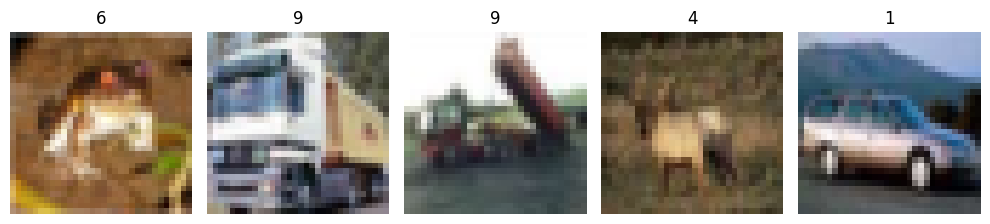

In [4]:
# display examples
plot_data_examples(full_train_dataset)

In [5]:
# FOR THIS LESSON: Subsample to a tiny dataset (e.g., 500 images total)
tiny_train_indices = torch.randperm(len(full_train_dataset))[:500]
tiny_train_dataset = Subset(full_train_dataset, tiny_train_indices)

print(f"Tiny training set size: {len(tiny_train_dataset)}")

Tiny training set size: 500


In [6]:
# don't forget normalizatoin
mean, std = get_mean_std(tiny_train_dataset)
print(f"mean={mean}, std={std}")

mean=tensor([0.4900, 0.4817, 0.4492]), std=tensor([0.2450, 0.2401, 0.2618])


In [7]:
# need to recrate normalized datasets
transform_composed = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_train_dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_composed)
test_dataset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform_composed)

In [8]:
# Recreate tiny train dataset (e.g., 500 images total)
tiny_train_dataset = Subset(full_train_dataset, tiny_train_indices)

# tiny validation
tiny_val_indices = torch.randperm(len(full_train_dataset))[:100]
tiny_val_dataset = Subset(full_train_dataset, tiny_val_indices)

print(f"Tiny training set size: {len(tiny_train_dataset)}")
print(f"Tiny validation set size: {len(tiny_val_dataset)}")

Tiny training set size: 500
Tiny validation set size: 100


<!-- FULL: keep, DEMO: keep -->
<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Train from scratch</strong>
</div>

Train on tiny dataset using basic CNN model

In [9]:
# Data Loaders
train_loader = DataLoader(tiny_train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(tiny_val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [10]:
# basic setups
model_scratch = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=0.001)
num_epochs = 50

In [11]:
# train model
model_scratch, train_losses, val_losses = train_model(model_scratch, train_loader, val_loader, criterion, optimizer, num_epochs, device)

Epoch 1:, train_loss=2.2667, val_loss=2.1989
Epoch 2:, train_loss=1.9935, val_loss=2.1552
Epoch 3:, train_loss=1.7636, val_loss=2.1533
Epoch 4:, train_loss=1.5662, val_loss=2.0628
Epoch 5:, train_loss=1.3569, val_loss=1.9596
Epoch 6:, train_loss=1.2556, val_loss=1.8919
Epoch 7:, train_loss=1.0829, val_loss=1.9220
Epoch 8:, train_loss=0.9476, val_loss=1.8558
Epoch 9:, train_loss=0.8158, val_loss=1.8528
Epoch 10:, train_loss=0.7168, val_loss=1.9681
Epoch 11:, train_loss=0.5923, val_loss=1.9518
Epoch 12:, train_loss=0.5450, val_loss=2.1011
Epoch 13:, train_loss=0.4654, val_loss=2.1139
Epoch 14:, train_loss=0.3688, val_loss=2.2274
Epoch 15:, train_loss=0.3237, val_loss=2.4756
Epoch 16:, train_loss=0.2620, val_loss=2.6031
Epoch 17:, train_loss=0.2015, val_loss=2.4532
Epoch 18:, train_loss=0.1589, val_loss=2.5338
Epoch 19:, train_loss=0.1366, val_loss=2.6889
Epoch 20:, train_loss=0.1137, val_loss=2.7686
Epoch 21:, train_loss=0.0887, val_loss=2.8392
Epoch 22:, train_loss=0.0800, val_loss=2.98

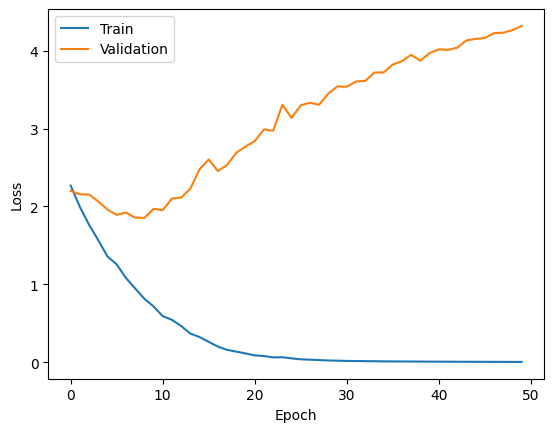

In [12]:
# plot losses
plot_losses(train_losses, val_losses)

In [13]:
# test model
scratch_accuracy = test_model(model_scratch, test_loader, device)
print(f"Scratch model test accuracy: {100*scratch_accuracy:.2f}%")

Scratch model test accuracy: 36.91%


<!-- FULL: keep, DEMO: keep -->
<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Finetuning</strong>
</div>

Use `torch.hub` to find model pretrained on 32x32 images

In [14]:
# list available models from a repository
models = torch.hub.list('chenyaofo/pytorch-cifar-models')
cifar10_resnets = [m for m in models if 'cifar10_resnet' in m.lower()]
print(cifar10_resnets)

['cifar10_resnet20', 'cifar10_resnet32', 'cifar10_resnet44', 'cifar10_resnet56']


Using cache found in /home/gregorovam/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [21]:
# get pretrained cifar10 model with weights
model_cifar10 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
print(model_cifar10)

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size

Using cache found in /home/gregorovam/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [57]:
# freeze backbone parameters
for param in model_cifar10.parameters():
    param.requires_grad = False
# replace fc head with new linear layer
model_cifar10.fc = nn.Linear(model_cifar10.fc.in_features, 10)

# alternatively
# for param in model_cifar10.fc.parameters():
#     param.requires_grad = True

In [58]:
# basic setups
model_cifar10 = model_cifar10.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cifar10.parameters(), lr=0.01)
num_epochs = 50

In [59]:
# train model
model_cifar10, train_losses, val_losses = train_model(model_cifar10, train_loader, val_loader, criterion, optimizer, num_epochs, device)

Epoch 1:, train_loss=1.3458, val_loss=0.5616
Epoch 2:, train_loss=0.4609, val_loss=0.2937
Epoch 3:, train_loss=0.2929, val_loss=0.2405
Epoch 4:, train_loss=0.2537, val_loss=0.2179
Epoch 5:, train_loss=0.2276, val_loss=0.1964
Epoch 6:, train_loss=0.2395, val_loss=0.1986
Epoch 7:, train_loss=0.1982, val_loss=0.1877
Epoch 8:, train_loss=0.2037, val_loss=0.1929
Epoch 9:, train_loss=0.1948, val_loss=0.1843
Epoch 10:, train_loss=0.1924, val_loss=0.1748
Epoch 11:, train_loss=0.1743, val_loss=0.1902
Epoch 12:, train_loss=0.1775, val_loss=0.1883
Epoch 13:, train_loss=0.2218, val_loss=0.1759
Epoch 14:, train_loss=0.1894, val_loss=0.1881
Epoch 15:, train_loss=0.2011, val_loss=0.1905
Epoch 16:, train_loss=0.2073, val_loss=0.1961
Epoch 17:, train_loss=0.1800, val_loss=0.1752
Epoch 18:, train_loss=0.1828, val_loss=0.1790
Epoch 19:, train_loss=0.1476, val_loss=0.1851
Epoch 20:, train_loss=0.1778, val_loss=0.1956
Epoch 21:, train_loss=0.1954, val_loss=0.1884
Epoch 22:, train_loss=0.1775, val_loss=0.19

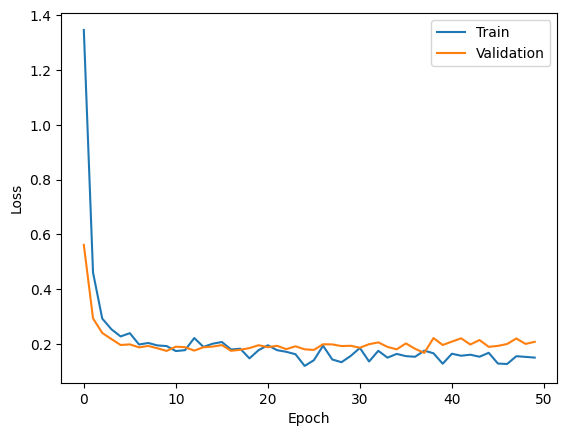

In [60]:
# plot losses
plot_losses(train_losses, val_losses)

In [61]:
# test model
scratch_accuracy = test_model(model_cifar10, test_loader, device)
print(f"Pretrained CIFAR10 model test accuracy: {100*scratch_accuracy:.2f}%")

Pretrained CIFAR10 model test accuracy: 88.02%
